In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rasterio as rio
import rioxarray as rxr
import matplotlib.pyplot as plt
from glob import glob
import re

In [2]:
## set date
date = "20230216"

In [ ]:
## function for calculating swe statistics for polygons
def swe_stat_calc(raster, shapefile_gdf):
    """
    Calculates snow water equivalent mean, median, and volume for each 
    polygon in a shapefile and returns it as a dataframe.

    Parameters:
    raster (xarray.DataArray): An xarray object with SWE raster data. Units must be in inches.
    shapefile_gdf (geopandas.GeoDataFrame): A GeoDataFrame with shapefile data.

    Returns:
    pandas.DataFrame: A DataFrame with one row for each polygon in shapefile and columns
                        for median, mean, and total swe volume. Mean and median units are
                        in inches and volume units are acre feet.
    """

    cols_swe = ['name', 'Median SWE (in.)', 'Mean SWE (in.)', 
                'Estimated Volume (af)'] #output column names
    swe_df = [] #empty list for polygon stats

    ## loop through each polygon in shapefile and append statistics to swe_df list
    for idx, basin in shapefile_gdf.iterrows():
        swe_basin = raster.rio.clip([basin.geometry])
        
        '''
        ## plot clipped polygon
        f, ax = plt.subplots()
        swe_basin.plot(cmap="Blues",
                        ax=ax)
        plt.show()'
        '''
        swe_median = np.nanmedian(swe_basin) # median swe for basin
        swe_mean = np.nanmean(swe_basin) # mean swe for basin
        swe_sum_inches = np.nansum(swe_basin) # swe sum for basin

        ## get pixel area in feet
        pixel_size_x, pixel_size_y = swe_basin.rio.resolution()
        pixel_area = abs((pixel_size_x*3.28084) * (pixel_size_y*3.28084))
        
        swe_vol_cuft = (swe_sum_inches / 12) * pixel_area # volume in cubic feet
        swe_vol_af = swe_vol_cuft / 43560 # volume in acre feet

        ## append values to list
        swe_df.append([basin['Name'], swe_median, 
                    swe_mean, swe_vol_af,])

    ## convert list to dataframe
    swe_df_table = pd.DataFrame(swe_df, columns=cols_swe)
    return(swe_df_table)

## Read raster and shapefile data

In [7]:
# Read/clip data
snodas_file = "../data/SNODAS/SNODAS_SWE_" + date + ".tif"
snodas = rxr.open_rasterio(snodas_file).sel(band=1).reset_coords('band', drop=True)
snodas_utm = snodas.rio.reproject('epsg:26913', resolution=1000)
huc6 = gpd.read_file('../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp').to_crs('epsg:26913')
huc8 = gpd.read_file('../data/Shapefiles/WBDHU8_RG/WBDHU8_RG.shp').to_crs('epsg:26913')
huc8 = huc8.drop(huc8.index[72]) #remove Rio Salado polygon in Mexico
ose = gpd.read_file('../data/Shapefiles/OSE_Basin_Designations/SubBasins_Dissolve.shp').to_crs('epsg:26913')

In [8]:
## filter data to polygons of interest
huc6_polys = ['Rio Grande Headwaters', 'Upper Rio Grande',
       'Rio Grande-Elephant Butte']
huc6 = huc6[huc6['Name'].isin(huc6_polys)]

huc8['Name'].unique()
huc8_polys = ['Rio Grande Headwaters', 'Alamosa-Trinchera',
              'San Luis', 'Saguache',
              'Conejos', 'Upper Rio Grande',
              'Rio Chama', 'Rio Grande-Santa Fe',
              'Jemez', 'Rio Grande-Albuquerque',
              'Arroyo Chico', 'North Plains',
              'Rio San Jose', 'Plains of San Agustin',
              'Rio Salado', 'Jornada Del Muerto',
              'Elephant Butte Reservoir', 'Rio Puerco']
huc8 = huc8[huc8['Name'].isin(huc8_polys)]

## sort by polygon order
huc8 = huc8.set_index('Name', drop = False)
huc8 = huc8.reindex(huc8_polys)

## filter ose polygons
ose = ose.loc[ose['SubBasin'] != 'San Juan River Basin']
ose = ose.rename(columns={'SubBasin': 'Name'}) 
ose = ose.replace({'Name' : {'JemezRiver Basin' : 'Jemez', 
                             'Rio Chama River Basin' : 'Rio Chama', 
                             'Sangre De Cristo Mountain Range Basins' : 'Sangre de Cristo',
                            'Upper Rio Grande Basin' : 'Upper Rio Grande' }})

## confirm CRS are all equal
ose.crs == huc8.crs == huc6.crs == snodas.rio.crs

## add huc6 basin and region columns to huc8 shapefile for table 1
## huc6 basins
huc6_basin = np.array(['Rio Grande Headwaters', 'Upper Rio Grande', 
                       'Rio Grande-Elephant Butte'])
huc6_basin = np.repeat(huc6_basin, [5, 2, 11], axis=0)

## region
region = np.repeat('Rio Grande', [18], axis = 0)

huc8['HUC6 Basin'] = huc6_basin
huc8['Region'] = region
huc8.head()
huc6.head()
ose.head()

,Name,Shape_Leng,Shape_Area,geometry
0,Jemez,3.398059e+05,4.163069e+09,"POLYGON ((370349.049 3987334.158, 370358.675 3..."
1,Rio Chama,5.521299e+05,1.268620e+10,"POLYGON ((397422.42 4071697.147, 397492.608 40..."
3,Sangre de Cristo,1.453554e+06,3.012485e+10,"POLYGON ((409807.589 4256822.09, 409962.715 42..."
4,Upper Rio Grande,1.114530e+06,1.436838e+10,"MULTIPOLYGON (((369074.948 4137353.159, 369155..."


## Clip SNODAS to HUC8 and plot

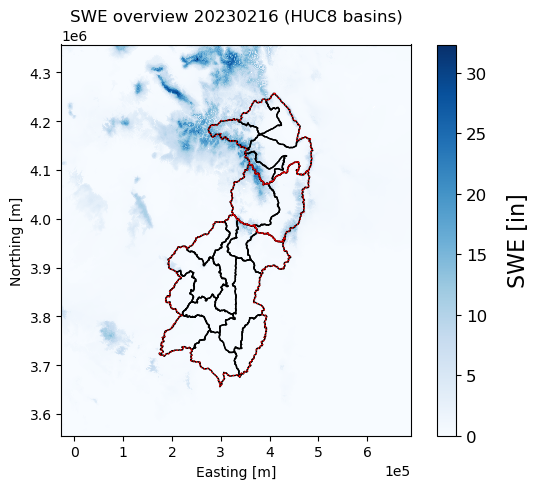

In [9]:
# clip SWE data to HUC8 bounds
bounds = huc8.total_bounds
xpad = 200000
ypad = 100000
bounds_padded = [bounds[0]-xpad, bounds[1]-ypad, bounds[2]+xpad, bounds[3]+ypad]
snodas_clip = snodas_utm.where(snodas_utm>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches

# Plot
fig, ax = plt.subplots(figsize=(6,5))
snodas_clip.plot(ax=ax, cmap='Blues')
cbar = ax.collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
huc8.plot(ax=ax, facecolor='none', edgecolor='k')
huc6.plot(ax=ax, facecolor='none', edgecolor = 'red', linestyle=":")
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('SWE overview ' + date + ' (HUC8 basins)')
plt.tight_layout()

## Loop for SWE calc by basin

In [ ]:
cols_swe = ['Region', 'HUC6 Basin', 'HUC8 Subbasin', 
            'Median SWE (in.)', 'Mean SWE (in.)', 'Estimated Volume (af)', 'Area (acres)']
swe_df = []

for idx, basin in huc8.iterrows():
    #print(basin['Name'])
    swe_basin = snodas_clip.rio.clip([basin.geometry])
    
    '''
    ## plot clipped polygon
    f, ax = plt.subplots()
    swe_basin.plot(cmap="Blues",
                     ax=ax)
    plt.show()'
    '''
    swe_median = np.nanmedian(swe_basin) # median swe basin
    swe_mean = np.nanmean(swe_basin)
    swe_sum_inches = np.nansum(swe_basin) # swe sum basin

    ## get pixel area in feet
    pixel_size_x, pixel_size_y = swe_basin.rio.resolution()
    pixel_area = abs((pixel_size_x*3.28084) * (pixel_size_y*3.28084))
    
    swe_vol_cuft = (swe_sum_inches / 12) * pixel_area # volume in cubic feet
    swe_vol_af = swe_vol_cuft / 43560 # volume in acre feet

    #swe_volume = swe_sum_inches/12 * pd.notnull(swe_basin).sum() / 247.105
    #print(pd.notnull(swe_basin).sum() * 247.105)

    swe_df.append([basin['Region'], basin['HUC6 Basin'],
                   basin['Name'], swe_median, swe_mean,
                   swe_vol_af, basin['AreaAcres']])

swe_df_table = pd.DataFrame(swe_df, columns=cols_swe)
swe_df_table



## Table 1

In [10]:
huc8_stats = swe_stat_calc(snodas_clip, huc8)
huc8_stats = huc8_stats.rename(columns={'name': 'HUC8 SubBasin'}) 
huc8_stats['HUC6 Basin'] = huc6_basin


huc6_stats = swe_stat_calc(snodas_clip, huc6)
huc6_stats = huc6_stats.rename(columns={'name': 'HUC6 Basin'})
huc6_stats['HUC8 SubBasin'] = np.repeat('Total', [3], axis=0)

#huc6_stats
table1 = pd.concat([huc8_stats, huc6_stats], ignore_index=True)
table1 = table1[['HUC6 Basin', 'HUC8 SubBasin', 'Median SWE (in.)', 
                 'Mean SWE (in.)', 'Estimated Volume (af)']]
table1

,HUC6 Basin,HUC8 SubBasin,Median SWE (in.),Mean SWE (in.),Estimated Volume (af)
0,Rio Grande Headwaters,Rio Grande Headwaters,9.055008,9.152621,6.730330e+05
1,Rio Grande Headwaters,Alamosa-Trinchera,0.708653,2.107893,2.850036e+05
2,Rio Grande Headwaters,San Luis,0.354326,1.148413,9.679230e+04
3,Rio Grande Headwaters,Saguache,1.692893,2.469007,1.771338e+05
4,Rio Grande Headwaters,Conejos,7.342431,8.293942,3.391886e+05
5,Upper Rio Grande,Upper Rio Grande,0.708653,2.567760,4.458472e+05
6,Upper Rio Grande,Rio Chama,1.771632,4.002467,6.736127e+05
7,Rio Grande-Elephant Butte,Rio Grande-Santa Fe,0.393696,0.519018,5.185664e+04
8,Rio Grande-Elephant Butte,Jemez,0.511805,2.646449,1.464852e+05
9,Rio Grande-Elephant Butte,Rio Grande-Albuquerque,0.000000,0.039852,6.830176e+03


## Table 2

In [13]:
huc8_ose_polys = ['Rio Grande Headwaters', 'Saguache',
                  'Conejos', 'San Luis',
                  'Alamosa-Trinchera', 'Upper Rio Grande']
huc8_ose = huc8[huc8['Name'].isin(huc8_ose_polys)]

## sort by polygon order
huc8_ose = huc8_ose.set_index('Name', drop = False)
huc8_ose = huc8_ose.reindex(huc8_ose_polys)

## add ose basin column
ose_grouping = np.array(['Upper Rio Grande', 
                       'Sangre de Cristo'])
ose_grouping = np.repeat(ose_grouping, [3, 3], axis=0)

huc8_ose['OSE Grouping'] = ose_grouping

## create table
huc8_ose_stats = swe_stat_calc(snodas_clip, huc8_ose)
huc8_ose_stats = huc8_ose_stats.rename(columns={'name': 'HUC8 SubBasin'}) 
huc8_ose_stats['OSE Grouping'] = ose_grouping


ose_stats = swe_stat_calc(snodas_clip, ose)
ose_stats = ose_stats.rename(columns={'name': 'OSE Grouping'})
ose_stats['HUC8 SubBasin'] = np.repeat('Total', [4], axis=0)

#huc6_stats
table2 = pd.concat([huc8_ose_stats, ose_stats], ignore_index=True)
table2 = table2[['OSE Grouping', 'HUC8 SubBasin', 'Median SWE (in.)', 
                 'Mean SWE (in.)', 'Estimated Volume (af)']]
table2

,OSE Grouping,HUC8 SubBasin,Median SWE (in.),Mean SWE (in.),Estimated Volume (af)
0,Upper Rio Grande,Rio Grande Headwaters,9.055008,9.152621,6.730330e+05
1,Upper Rio Grande,Saguache,1.692893,2.469007,1.771338e+05
2,Upper Rio Grande,Conejos,7.342431,8.293942,3.391886e+05
3,Sangre de Cristo,San Luis,0.354326,1.148413,9.679230e+04
4,Sangre de Cristo,Alamosa-Trinchera,0.708653,2.107893,2.850036e+05
5,Sangre de Cristo,Upper Rio Grande,0.708653,2.567760,4.458472e+05
6,Jemez,Total,0.511805,2.642906,1.487381e+05
7,Rio Chama,Total,1.771632,4.011074,6.755568e+05
8,Sangre de Cristo,Total,0.669283,2.097386,8.260444e+05
9,Upper Rio Grande,Total,4.881830,6.402134,1.185710e+06


## Table 3 (Elevation bands)

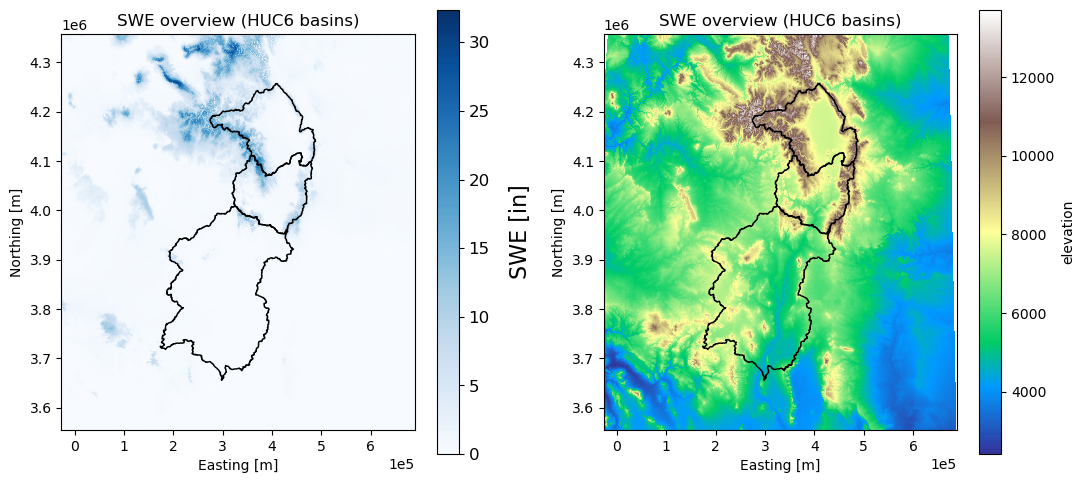

In [ ]:
## read DEM 
dem = rxr.open_rasterio('../data/dem.tif').sel(band=1).reset_coords('band', drop=True)
dem = dem.where(dem>=0).rio.reproject_match(snodas_clip)

## combine swe and dem arrays
swe_ds = xr.Dataset()
swe_ds['swe'] = snodas_clip
swe_ds['elevation'] = dem

## plot
fig, ax = plt.subplots(1, 2, figsize=(11,5))
swe_ds.swe.plot(ax=ax[0], cmap='Blues')
swe_ds.elevation.plot(ax=ax[1], cmap='terrain')
cbar = ax[0].collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
huc6.plot(ax=ax[0], facecolor='none', edgecolor='k')
huc6.plot(ax=ax[1], facecolor='none', edgecolor='k')
for axx in ax.flatten():
    axx.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
    axx.set_xlabel('Easting [m]')
    axx.set_ylabel('Northing [m]')
    axx.set_title('SWE overview (HUC6 basins)')
plt.tight_layout()

In [ ]:
## get pixel area in feet
pixel_size_x, pixel_size_y = swe_basin.rio.resolution()
pixel_area = abs((pixel_size_x*3.28084) * (pixel_size_y*3.28084))
        

cols_swe_elev = ['HUC6 Basin', 'HUC8 Subbasin', 'Elevation Band (ft.)',
                 'Median SWE (in.)', 'Mean SWE (in.)', 
                 'Estimated Volume (af)'] #output column names
swe_elev_df = [] #empty list for polygon stats

for idx, basin in huc8.iterrows():
    swe_basin = swe_ds.rio.clip([basin.geometry])
    '''
    f, ax = plt.subplots()
    swe_basin.elevation.plot(cmap="terrain",
                            ax=ax)
    plt.show()
    '''

    ## get min and max elevation for basin
    elev_min = np.floor(float(np.nanmin(swe_basin.elevation)) / 1000) * 1000
    elev_max = np.ceil(float(np.nanmax(swe_basin.elevation)) / 1000) * 1000
    elev_bands = np.arange(elev_min, elev_max, 1000)

    ## loop through elevation bands and calculate statistics
    for i in range(len(elev_bands)):
        elev_mask = (swe_basin['elevation'] >= elev_bands[i]) * (swe_basin['elevation'] < elev_bands[i] + 1000)
        swe_sum_inches = float(swe_basin['swe'].where(elev_mask).sum()) # sum swe at mask
        swe_vol_cuft = (swe_sum_inches / 12) * pixel_area # volume in cubic feet
        swe_vol_af = swe_vol_cuft / 43560 # volume in acre feet

        ## swe median and mean at mask
        swe_median = float(swe_basin['swe'].where(elev_mask).median())
        swe_mean = float(swe_basin['swe'].where(elev_mask).mean())

        band = str(int(elev_bands[i])) + '-' + str(int(elev_bands[i] + 1000)) + "\'"

        ## append values to list
        swe_elev_df.append([basin['HUC6 Basin'], basin['Name'], band, 
                    swe_median, swe_mean, swe_vol_af,])

## convert list to dataframe
pd.set_option("display.max_rows", None, "display.max_columns", None) # no limit on max rows or columns for printing

swe_elev_table = pd.DataFrame(swe_elev_df, columns=cols_swe_elev)
swe_elev_table



,HUC6 Basin,HUC8 Subbasin,Elevation Band (ft.),Median SWE (in.),Mean SWE (in.),Estimated Volume (af)
0,Rio Grande Headwaters,Rio Grande Headwaters,7000-8000',0.669283,0.654285,282.935498
1,Rio Grande Headwaters,Rio Grande Headwaters,8000-9000',1.811002,2.192967,20004.916856
2,Rio Grande Headwaters,Rio Grande Headwaters,9000-10000',5.078679,5.991597,85131.972028
3,Rio Grande Headwaters,Rio Grande Headwaters,10000-11000',10.511683,10.955997,238466.783231
4,Rio Grande Headwaters,Rio Grande Headwaters,11000-12000',11.495924,11.940322,261366.724924
5,Rio Grande Headwaters,Rio Grande Headwaters,12000-13000',11.377815,11.147143,66797.095422
6,Rio Grande Headwaters,Rio Grande Headwaters,13000-14000',8.897530,7.952660,982.572556
7,Rio Grande Headwaters,Alamosa-Trinchera,7000-8000',0.629914,0.573552,34534.344202
8,Rio Grande Headwaters,Alamosa-Trinchera,8000-9000',0.629914,0.857296,27769.024544
9,Rio Grande Headwaters,Alamosa-Trinchera,9000-10000',2.244067,3.349038,67308.650650


In [ ]:
## check if elevation sums match totals from table 1
swe_elev_table.groupby(['HUC8 Subbasin'], sort = False)['Estimated Volume (af)'].sum()

HUC8 Subbasin
Rio Grande Headwaters       673033.000515
Alamosa-Trinchera           285003.597919
San Luis                     96792.313676
Saguache                    177133.825945
Conejos                     339188.586737
Upper Rio Grande            445847.157175
Rio Chama                   673612.664323
Rio Grande-Santa Fe          51856.643874
Jemez                       146485.192333
Rio Grande-Albuquerque        6830.176109
Arroyo Chico                 16505.111391
North Plains                 15254.195549
Rio San Jose                 61409.971482
Plains of San Agustin        31215.325013
Rio Salado                    6976.914059
Jornada Del Muerto             683.422992
Elephant Butte Reservoir      6753.970065
Rio Puerco                   33206.411898
Name: Estimated Volume (af), dtype: float64